In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import shap
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('StressLevelDataset.csv')

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [5]:
X = df.drop('stress_level', axis=1)
y = df['stress_level']

In [6]:
model = pickle.load(open('/content/stress_model.pkl', 'rb'))

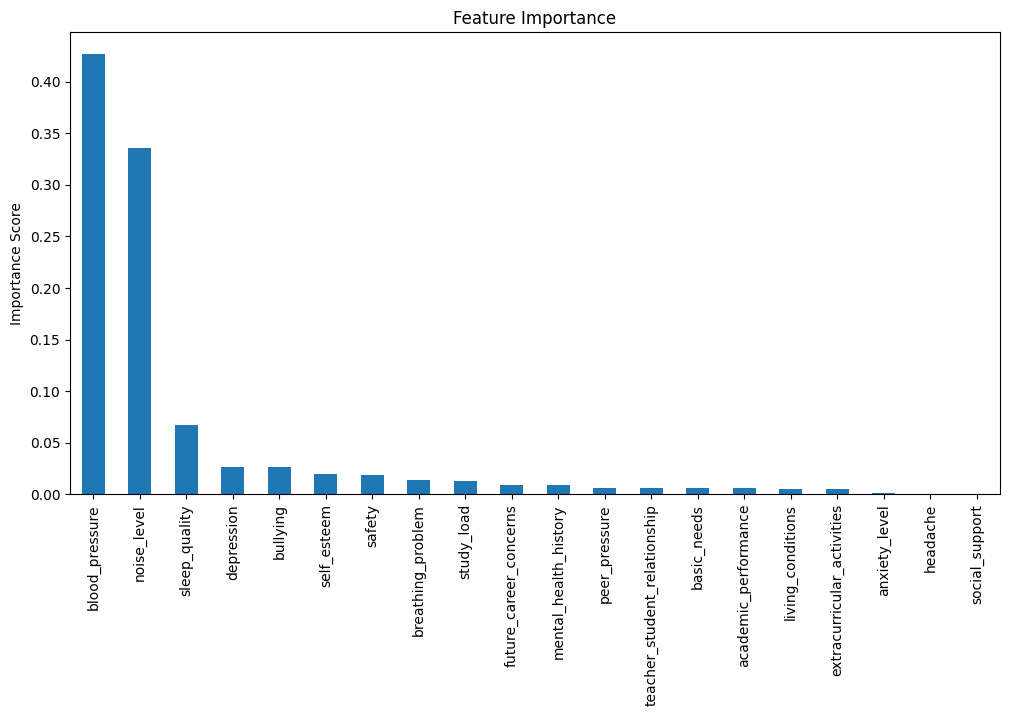

In [7]:
#FEATURE IMPORTANCE GRAPH
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.show()

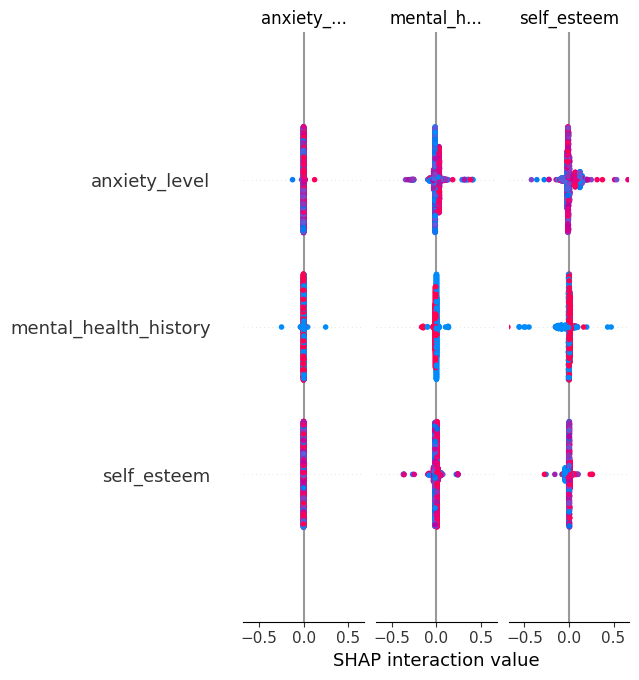

In [8]:
#SHAP Explainability
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [10]:
df.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')

In [12]:
df['mental_health_history'].value_counts()

,count
mental_health_history,
0,558
1,542


In [13]:
pd.crosstab(df['mental_health_history'], df['stress_level'])

stress_level,0,1,2
mental_health_history,,,
0,335,183,40
1,38,175,329


## Bias Mitigation Recommendations

1. Use balanced datasets across demographic groups.
2. Regularly audit model predictions for fairness.
3. Remove biased or highly sensitive features if necessary.
4. Use explainable AI tools such as SHAP for transparency.
5. Continuously retrain the model with diverse data.